In [9]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

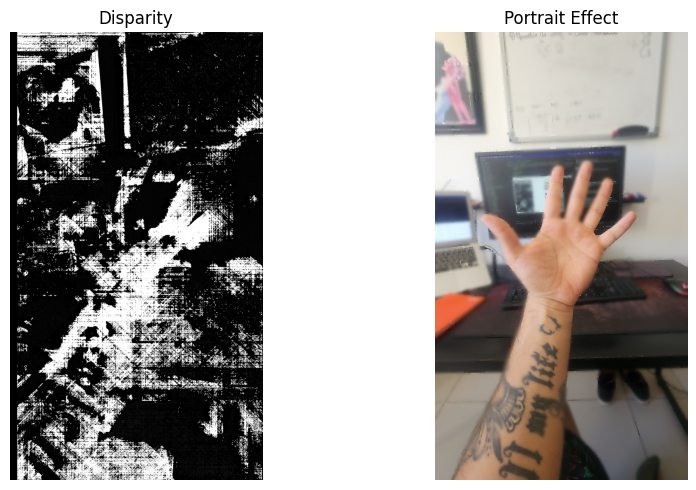

In [8]:
imgL = cv.imread('/Users/luryand/Documents/VC/img/task04/side_l.jpg')
imgR = cv.imread('/Users/luryand/Documents/VC/img/task04/side_r.jpg')
imgL_gray = cv.cvtColor(imgL, cv.COLOR_BGR2GRAY)
imgR_gray = cv.cvtColor(imgR, cv.COLOR_BGR2GRAY)

stereo = cv.StereoSGBM_create(
    minDisparity=0,
    numDisparities=64,
    blockSize=5,
    P1=8*3*9**2,
    P2=32*3*9**2,
    disp12MaxDiff=1,
    uniquenessRatio=15,
    speckleWindowSize=20,
    speckleRange=16
)
disparity = stereo.compute(imgL_gray, imgR_gray)

disp_norm = cv.normalize(disparity, None, 0 , 255, cv.NORM_MINMAX).astype(np.uint8)

_, mask_foreground = cv.threshold(disp_norm, 190, 255, cv.THRESH_BINARY)

mask_background = cv.bitwise_not(mask_foreground)

blurred = cv.GaussianBlur(imgL, (61, 61), 0)
blurred = cv.GaussianBlur(blurred, (41, 41), 0)

foreground = cv.bitwise_and(imgL, imgL, mask=mask_foreground)
background = cv.bitwise_and(blurred, blurred, mask=mask_background)
result = cv.add(foreground, background)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(disp_norm, cmap='gray')
plt.title('Disparity')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.title('Portrait Effect')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
import urllib
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

def load_image_from_url(url):
    with urllib.request.urlopen(url) as response:
        img_array = np.asarray(bytearray(response.read()), dtype=np.uint8)
        return cv.imdecode(img_array, cv.IMREAD_COLOR)

BASE_URL = "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04"
# Supondo que você tenha pares 01-02, 03-04, 05-06, etc.
num_pares = 3  # ajuste conforme o número de pares que você tem

for i in range(1, num_pares + 1):
    idxL = f"{2*i-1:02d}"
    idxR = f"{2*i:02d}"
    imgL_url = f"{BASE_URL}/{idxL}.jpg"
    imgR_url = f"{BASE_URL}/{idxR}.jpg"

    imgL = load_image_from_url(imgL_url)
    imgR = load_image_from_url(imgR_url)
    if imgL is None or imgR is None:
        print(f"Falha ao carregar par {idxL}-{idxR}")
        continue

    imgL_gray = cv.cvtColor(imgL, cv.COLOR_BGR2GRAY)
    imgR_gray = cv.cvtColor(imgR, cv.COLOR_BGR2GRAY)

    block_size = 7
    num_disp = 64
    stereo = cv.StereoSGBM_create(
        minDisparity=0,
        numDisparities=num_disp,
        blockSize=block_size,
        P1=8*3*block_size**2,
        P2=32*3*block_size**2,
        disp12MaxDiff=1,
        uniquenessRatio=12,
        speckleWindowSize=20,
        speckleRange=16
    )
    disparity = stereo.compute(imgL_gray, imgR_gray)
    disp_norm = cv.normalize(disparity, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    _, mask_foreground = cv.threshold(disp_norm, 120, 255, cv.THRESH_BINARY)
    mask_background = cv.bitwise_not(mask_foreground)
    blurred = cv.GaussianBlur(imgL, (31, 31), 0)
    foreground = cv.bitwise_and(imgL, imgL, mask=mask_foreground)
    background = cv.bitwise_and(blurred, blurred, mask=mask_background)
    result = cv.add(foreground, background)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(disp_norm, cmap='gray')
    plt.title(f'Disparity {idxL}-{idxR}')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    plt.title(f'Portrait Effect {idxL}-{idxR}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

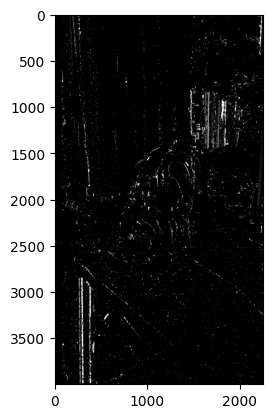

In [4]:
imgL = cv.imread('../../img/task04/side_r1.jpg', 0)
imgR = cv.imread('../../img/task04/side_l1.jpg', 0)
stereo = cv.StereoBM_create(numDisparities=64, blockSize=15)
disparity = stereo.compute(imgL,imgR)
plt.imshow(disparity,'gray')
plt.show()